Import Library dan Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

In [2]:
df = pd.read_csv("Kelas G_Fixed Call Report.csv")

df.head()


,Year,Month,Total Number of Calls,Total Number of Doctors Consultancy,Number of Total Health Information,Number of Total Ambulance Information,Number of Total Complaints,Number of Calls To Know About The Service
0,2025,Feb,155200,98964,3777,5773,3706,42980
1,2025,Jan,130982,87815,3217,4179,3178,32593
2,2024,Dec,133725,86832,3634,3735,3035,36489
3,2024,Nov,153698,93710,3010,4421,4133,48424
4,2024,Oct,214604,108207,6307,5792,8885,80804


In [32]:
print("Shape:", df.shape)

print("\nNama Kolom:")
print(df.columns.tolist())

Shape: (107, 9)

Nama Kolom:
['Year', 'Month', 'Total Number of Calls', 'Total Number of Doctors Consultancy', 'Number of Total Health Information', 'Number of Total Ambulance Information', 'Number of Total Complaints', 'Number of Calls To Know About The Service', 'Complaint Percentage']


In [33]:
df.isnull().sum()

Year                                         0
Month                                        0
Total Number of Calls                        0
Total Number of Doctors Consultancy          0
Number of Total Health Information           0
Number of Total Ambulance Information        0
Number of Total Complaints                   0
Number of Calls To Know About The Service    0
Complaint Percentage                         0
dtype: int64

Kategori A (Agregasi)
Soal : Hitung nilai maksimum panggilan pencarian informasi layanan (Number of Calls To Know About The Service) untuk tiap tahunnya. Tampilkan dalam Bar Chart

In [34]:
max_service = (
    df.groupby('Year')['Number of Calls To Know About The Service']
      .max()
      .reset_index()
)

max_service

,Year,Number of Calls To Know About The Service
0,2016,19698
1,2017,32241
2,2018,27948
3,2019,50963
4,2020,342434
5,2021,104105
6,2022,60846
7,2023,43221
8,2024,80804
9,2025,42980


C:\Users\Acer\AppData\Local\Temp\ipykernel_14828\3573666697.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


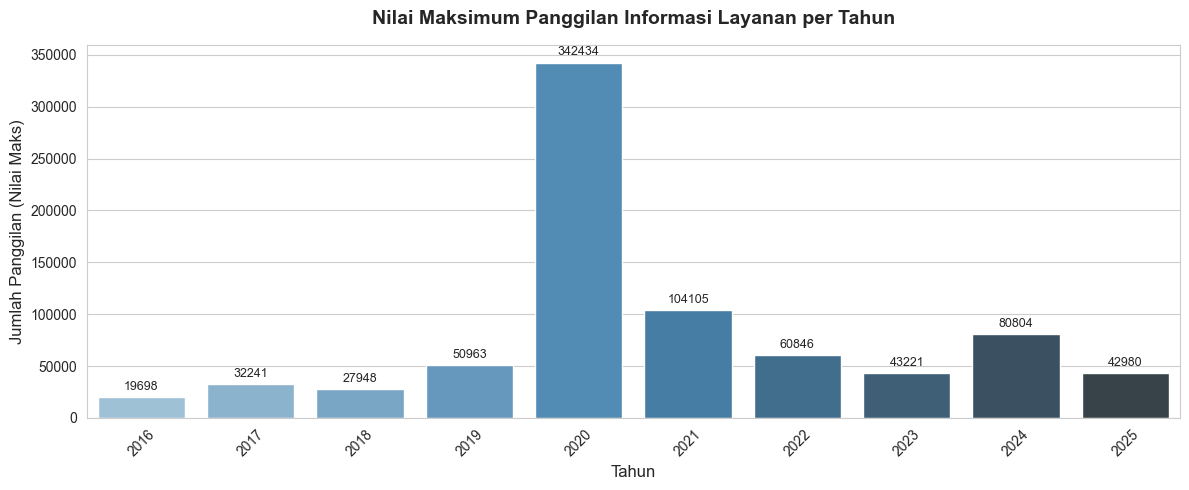

In [35]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=max_service,
    x='Year',
    y='Number of Calls To Know About The Service',
    palette='Blues_d',
    ax=ax
)

ax.set_title('Nilai Maksimum Panggilan Informasi Layanan per Tahun',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tahun', fontsize=12)
ax.set_ylabel('Jumlah Panggilan (Nilai Maks)', fontsize=12)
ax.tick_params(axis='x', rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

Kategori B (Tren/Filter)

In [36]:
bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June',
         'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']

df_2022 = df[df['Year'] == 2022].copy()

df_2022['Month'] = pd.Categorical(
    df_2022['Month'],
    categories=bulan,
    ordered=True
)

df_2022 = df_2022.sort_values('Month')

df_2022[['Month', 'Total Number of Doctors Consultancy']]

,Month,Total Number of Doctors Consultancy
37,Jan,184392
36,Feb,161242
35,Mar,138630
34,Apr,103252
33,May,103472
32,June,118428
31,July,104169
30,Aug,96837
29,Sept,87695
28,Oct,80186


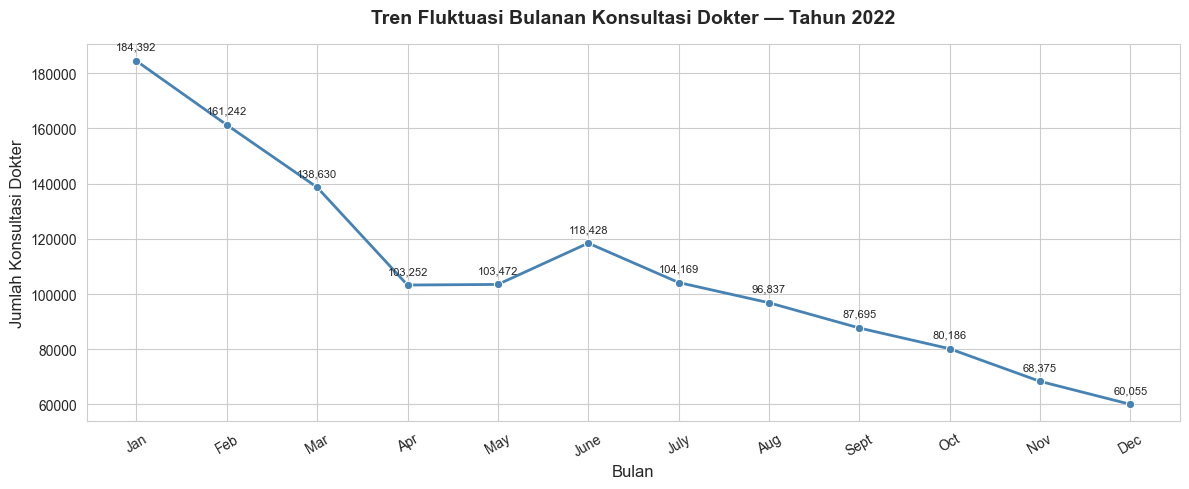

In [37]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=df_2022,
    x='Month',
    y='Total Number of Doctors Consultancy',
    marker='o',
    linewidth=2,
    color='steelblue',
    ax=ax
)

# Annotasi nilai di setiap titik
for _, row in df_2022.iterrows():
    ax.annotate(
        f"{int(row['Total Number of Doctors Consultancy']):,}",
        xy=(row['Month'], row['Total Number of Doctors Consultancy']),
        xytext=(0, 8), textcoords='offset points',
        ha='center', fontsize=8
    )

ax.set_title('Tren Fluktuasi Bulanan Konsultasi Dokter — Tahun 2022',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bulan', fontsize=12)
ax.set_ylabel('Jumlah Konsultasi Dokter', fontsize=12)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Kategori C (Korelasi)

In [38]:
# Hitung Complaint_Percentage
df['Complaint_Percentage'] = (
    df['Number of Total Complaints'] / df['Total Number of Calls']
) * 100

df[['Year', 'Month', 'Number of Total Complaints',
    'Total Number of Calls', 'Complaint_Percentage']].head(10)

,Year,Month,Number of Total Complaints,Total Number of Calls,Complaint_Percentage
0,2025,Feb,3706,155200,2.387887
1,2025,Jan,3178,130982,2.426288
2,2024,Dec,3035,133725,2.269583
3,2024,Nov,4133,153698,2.689040
4,2024,Oct,8885,214604,4.140184
5,2024,Sept,4286,157686,2.718060
6,2024,Aug,5267,168418,3.127338
7,2024,July,5040,190861,2.640665
8,2024,June,5414,169089,3.201864
9,2024,May,5037,149502,3.369186


In [40]:
corr_val = df['Total Number of Doctors Consultancy'].corr(
    df['Complaint_Percentage']
)

print(f"Nilai Korelasi (r) = {corr_val:.4f}")

Nilai Korelasi (r) = 0.0964


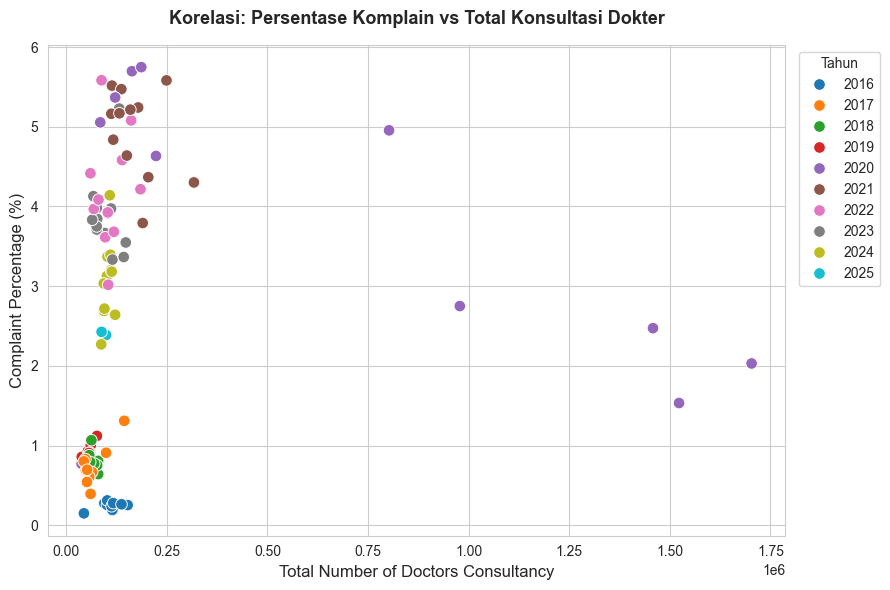

In [45]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Total Number of Doctors Consultancy',
    y='Complaint_Percentage',
    hue='Year',
    palette='tab10',
    s=70,
    ax=ax
)

# Garis tren regresi

ax.set_title(
    f'Korelasi: Persentase Komplain vs Total Konsultasi Dokter',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Total Number of Doctors Consultancy', fontsize=12)
ax.set_ylabel('Complaint Percentage (%)', fontsize=12)
ax.legend(title='Tahun', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

Kategori D (Distribusi)

C:\Users\Acer\AppData\Local\Temp\ipykernel_14828\155163663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


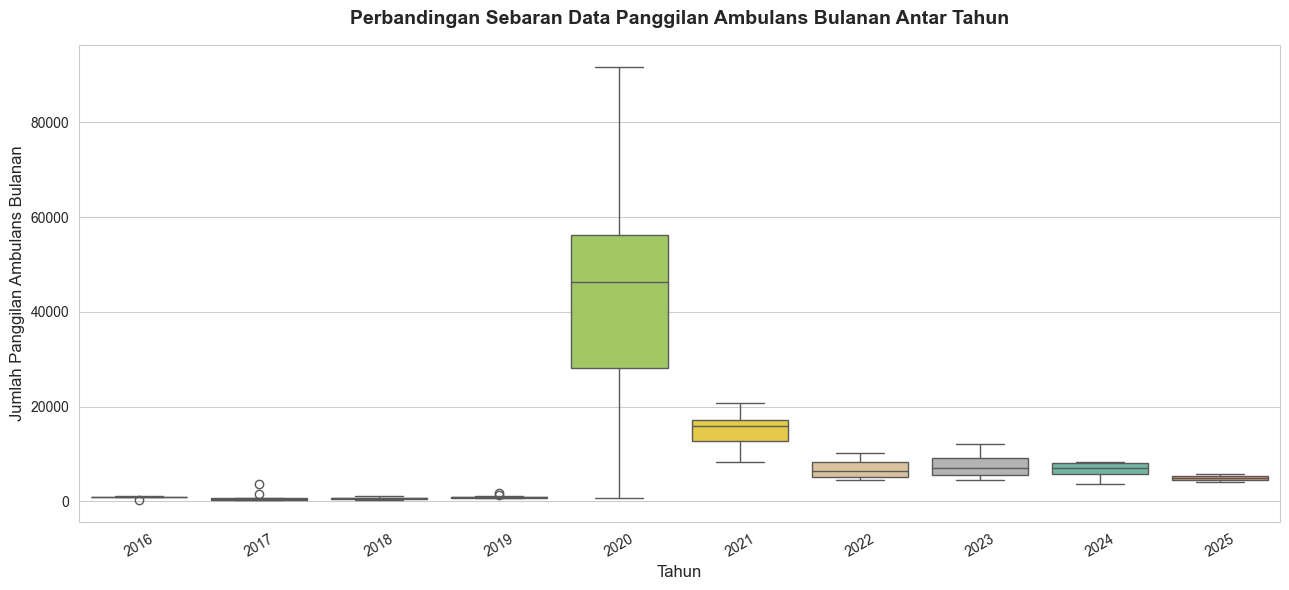

In [42]:
fig, ax = plt.subplots(figsize=(13, 6))

sns.boxplot(
    data=df,
    x='Year',
    y='Number of Total Ambulance Information',
    palette='Set2',
    ax=ax
)

ax.set_title(
    'Perbandingan Sebaran Data Panggilan Ambulans Bulanan Antar Tahun',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Tahun', fontsize=12)
ax.set_ylabel('Jumlah Panggilan Ambulans Bulanan', fontsize=12)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
Grafik 5 (Gabungan)

C:\Users\Acer\AppData\Local\Temp\ipykernel_14828\3822653849.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Acer\AppData\Local\Temp\ipykernel_14828\3822653849.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


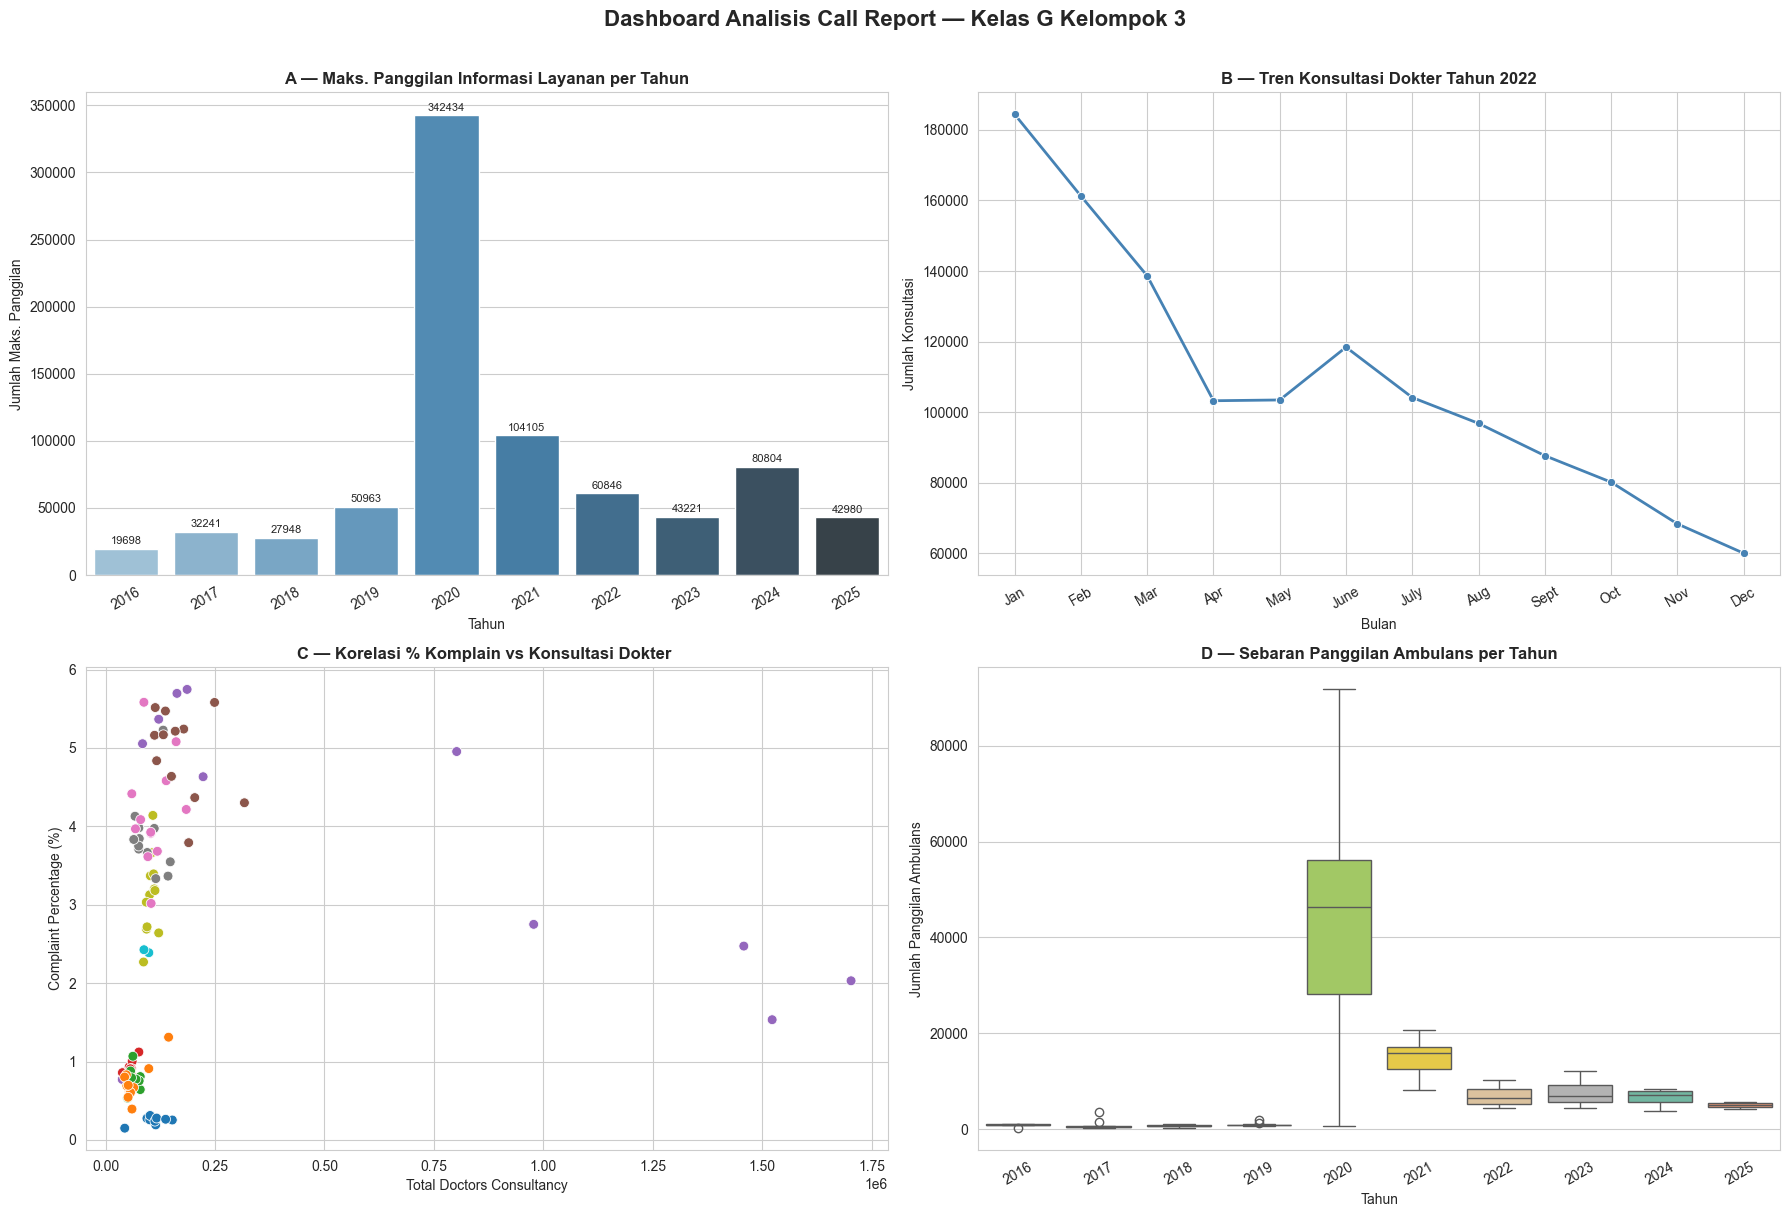

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    'Dashboard Analisis Call Report — Kelas G Kelompok 3',
    fontsize=16, fontweight='bold', y=1.01
)

# ── Subplot A: Agregasi ──────────────────────────────────
sns.barplot(
    data=max_service,
    x='Year',
    y='Number of Calls To Know About The Service',
    palette='Blues_d',
    ax=axes[0, 0]
)
axes[0, 0].set_title('A — Maks. Panggilan Informasi Layanan per Tahun',
                     fontweight='bold')
axes[0, 0].set_xlabel('Tahun')
axes[0, 0].set_ylabel('Jumlah Maks. Panggilan')
axes[0, 0].tick_params(axis='x', rotation=30)
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%.0f', fontsize=8, padding=2)

# ── Subplot B: Tren ──────────────────────────────────────
sns.lineplot(
    data=df_2022,
    x='Month',
    y='Total Number of Doctors Consultancy',
    marker='o',
    linewidth=2,
    color='steelblue',
    ax=axes[0, 1]
)
axes[0, 1].set_title('B — Tren Konsultasi Dokter Tahun 2022',
                     fontweight='bold')
axes[0, 1].set_xlabel('Bulan')
axes[0, 1].set_ylabel('Jumlah Konsultasi')
axes[0, 1].tick_params(axis='x', rotation=30)

# ── Subplot C: Korelasi ──────────────────────────────────
sns.scatterplot(
    data=df,
    x='Total Number of Doctors Consultancy',
    y='Complaint_Percentage',
    hue='Year',
    palette='tab10',
    s=50,
    legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title(f'C — Korelasi % Komplain vs Konsultasi Dokter ',
                     fontweight='bold')
axes[1, 0].set_xlabel('Total Doctors Consultancy')
axes[1, 0].set_ylabel('Complaint Percentage (%)')

# ── Subplot D: Distribusi ────────────────────────────────
sns.boxplot(
    data=df,
    x='Year',
    y='Number of Total Ambulance Information',
    palette='Set2',
    ax=axes[1, 1]
)
axes[1, 1].set_title('D — Sebaran Panggilan Ambulans per Tahun',
                     fontweight='bold')
axes[1, 1].set_xlabel('Tahun')
axes[1, 1].set_ylabel('Jumlah Panggilan Ambulans')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()